**Overview**

This notebook implements the **Image-to-Text Fusion pipeline** for the Fake News Detection project using the **AMG (Attribution Multi-Granularity)** dataset.

It addresses the core limitation of the visual-only pipeline: information loss caused by reducing images to generic ImageNet/Places365 labels. Instead, this pipeline converts each image into a natural-language description via BLIP captioning, then fuses that AI-generated description with the **original post text already present in AMG** (`content` field) to make a richer prediction.

The goal of this notebook is to:
- Replace weak visual concept labels with richer BLIP-generated captions
- Exploit AMG's `content` field (original social media post text) as a second textual view
- Use semantic alignment between the caption and the original post as a discriminative fake-news signal
- Add an LLM reasoning layer to fuse all signals into a final decision

---

This pipeline has three signal layers:

1. **BLIP Captioning Layer** 
`Salesforce/blip-image-captioning-base` generates a natural-language description of each image.

2. **RoBERTa Prediction Layer** 
`hamzab/roberta-fake-news-classification` classifies both the original post text and the BLIP caption **independently**, producing:
    - `fake` or `real` + confidence score for the **content text**
    - `fake` or `real` + confidence score for the **BLIP caption**

3. **Semantic Similarity Layer** 
`all-mpnet-base-v2` (SentenceTransformers) computes cosine similarity between the original post text and the BLIP caption.
    - High similarity → image matches what the post claims → likely real
    - Low similarity → image does not match the post text → potential manipulation

4. **LLM Reasoning Layer** 
`gpt-4.1-mini` via OpenRouter fuses all signals and returns:
    - Decision (Fake / Real)
    - Short explanation
    - Nudge (user-facing actionable advice)

---

**Why AMG is well-suited for this approach** 
AMG's fake categories map directly onto text-image misalignment:
- `entity_inconsistency` → caption describes a different person/object than the post claims
- `event_inconsistency` → image is from a different event than described
- `time_space_inconsistency` → old image reused in a new context
- `image_fabrication` → image is synthetic or heavily manipulated

In all these cases, the MPNet similarity score between the BLIP caption and the post content should be lower than for real news, giving the LLM a grounded signal beyond generic scene labels.

---

**AMG Label Schema** 
- `0` → Real News → binary **1** (Real) 
- `1–5` → any fake type → binary **0** (Fake)

## 1. Setup Dependencies

In this section we import all required libraries and initialize the main resources used throughout the notebook.

This includes:
- **BLIP** (`Salesforce/blip-image-captioning-base`) for image-to-text captioning
- **RoBERTa** (`hamzab/roberta-fake-news-classification`) for text classification on both content and captions
- **MPNet** (`all-mpnet-base-v2`) for semantic similarity between content and caption
- **OpenRouter** for the LLM reasoning layer
- scikit-learn, matplotlib, and seaborn for evaluation and visualization

Configuration variables:
- `AMG_SPLIT` — which split to use (`train`, `val`, or `test`)
- `MAX_ROWS` — number of samples (200)
- `RANDOM_STATE` — fixed seed for reproducibility

In [2]:
# ============================================================
# IMAGE-TO-TEXT FUSION PIPELINE — AMG Dataset
# Structure:
# 1) Setup dependencies
# 2) Dataset loading
# 3) BLIP captioning layer
# 4) Text similarity layer (MPNet)
# 5) RoBERTa prediction layer (content + caption)
# 6) OpenRouter LLM reasoning layer
# 7) Evaluation
# 8) Dataset inspection + error analysis
# ============================================================

# ============================================================
# 1. SETUP DEPENDENCIES
# ============================================================

import os
import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
from PIL import Image, ImageFile
from dotenv import load_dotenv
# Allow PIL to load truncated/corrupted image files without raising an error
ImageFile.LOAD_TRUNCATED_IMAGES = True
# BLIP captioning
from transformers import BlipProcessor, BlipForConditionalGeneration

# RoBERTa classification
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Semantic similarity
from sentence_transformers import SentenceTransformer, util as st_util

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# OpenRouter
from openai import OpenAI

print("--- [1] Setup complete ---")

# ---------------- CONFIG ----------------
AMG_DATASET_DIR  = Path("../Datasets")
AMG_SPLIT        = "test"   # "train", "val", or "test"

MAX_ROWS         = 200
RANDOM_STATE     = 42

BLIP_MODEL_NAME  = "Salesforce/blip-image-captioning-base"
ROBERTA_MODEL    = "hamzab/roberta-fake-news-classification"
MPNET_MODEL      = "all-mpnet-base-v2"
OPENROUTER_MODEL = "openai/gpt-4.1-mini"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load .env from parent folder
load_dotenv(dotenv_path=Path("../.env"))
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
if not openrouter_api_key:
    raise ValueError(
        "Missing OPENROUTER_API_KEY. Set it in the .env file before running."
    )

client = OpenAI(
    api_key=openrouter_api_key,
    base_url="https://openrouter.ai/api/v1"
)

c:\Users\anapa\anaconda3\envs\FakeNewsAP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- [1] Setup complete ---
Using device: cpu


## 2. Dataset Loading

We load the AMG annotation JSON and match each entry to its image in `Datasets/AMG_MEDIA/{split}/`.

AMG provides **both modalities** for each sample:
- `content` — the original social media post text that accompanied the image
- `{Id}.jpg` — the image file

This makes AMG ideal for a fusion approach: the `content` plays the role of `clean_title` from Fakeddit, but carries richer, longer text from the original social media post.

Only entries for which a matching `.jpg` file exists are kept. We then sample 200 rows.

In [3]:
# ============================================================
# 2. DATASET LOADING (AMG — content text + image)
# ============================================================

print("--- [2] Dataset loading: AMG fusion ---")

AMG_LABEL_NAMES = {
    0: "real_news",
    1: "image_fabrication",
    2: "entity_inconsistency",
    3: "event_inconsistency",
    4: "time_space_inconsistency",
    5: "ineffective_visual_information",
}


def amg_label_name(x):
    try:
        return AMG_LABEL_NAMES.get(int(x), "unknown")
    except Exception:
        return "unknown"


def normalize_label_amg(label_value):
    """
    Binary mapping:
      0          -> 1  (Real)
      1,2,3,4,5  -> 0  (Fake)
    """
    try:
        x = int(label_value)
    except Exception:
        return None
    if x == 0:
        return 1
    if x in {1, 2, 3, 4, 5}:
        return 0
    return None


# Paths
json_path = AMG_DATASET_DIR / f"{AMG_SPLIT}.json"
img_dir   = AMG_DATASET_DIR / "AMG_MEDIA" / AMG_SPLIT

if not json_path.exists():
    raise FileNotFoundError(f"Annotation file not found: {json_path}")
if not img_dir.exists():
    raise FileNotFoundError(f"Image directory not found: {img_dir}")

with open(json_path, encoding="utf-8") as f:
    raw_data = json.load(f)

# Build a set of available image IDs
available_ids = {p.stem for p in img_dir.glob("*.jpg")}
print(f"\nImages in {AMG_SPLIT}/     : {len(available_ids)}")
print(f"Entries in {AMG_SPLIT}.json: {len(raw_data)}")

# Match annotation entries to images, keep content text
matched = [
    {
        "orig_id"    : row["Id"],
        "content"    : str(row["content"]).strip(),
        "image_path" : str(img_dir / f"{row['Id']}.jpg"),
        "label_raw"  : row["label"],
        "label_name" : amg_label_name(row["label"]),
        "label"      : normalize_label_amg(row["label"]),
    }
    for row in raw_data
    if str(row["Id"]) in available_ids
    and normalize_label_amg(row["label"]) is not None
    and str(row["content"]).strip() != ""
]

print(f"Matched (annotation + image + content): {len(matched)}")

# Show original AMG label breakdown
full_df = pd.DataFrame(matched)
print(f"\nOriginal AMG label counts (matched {AMG_SPLIT} set):")
raw_counts = pd.to_numeric(full_df["label_raw"], errors="coerce").dropna().astype(int).value_counts().sort_index()
for lbl, cnt in raw_counts.items():
    print(f"  {lbl} = {amg_label_name(lbl):<32s} -> {cnt}")

# Sample
if MAX_ROWS is not None:
    image_df = full_df.sample(min(MAX_ROWS, len(full_df)), random_state=RANDOM_STATE).reset_index(drop=True)
else:
    image_df = full_df.reset_index(drop=True)

print(f"\nRows used after sampling : {len(image_df)}")
print("\nBinary label distribution (sample):")
print(image_df["label"].value_counts().sort_index())   # 0=Fake, 1=Real

--- [2] Dataset loading: AMG fusion ---

Images in test/     : 427
Entries in test.json: 979
Matched (annotation + image + content): 424

Original AMG label counts (matched test set):
  0 = real_news                        -> 386
  1 = image_fabrication                -> 3
  2 = entity_inconsistency             -> 15
  3 = event_inconsistency              -> 11
  4 = time_space_inconsistency         -> 5
  5 = ineffective_visual_information   -> 4

Rows used after sampling : 200

Binary label distribution (sample):
label
0     18
1    182
Name: count, dtype: int64


In [4]:
# Preview — confirm we have both text and image path
pd.set_option('display.max_colwidth', 80)
image_df[["orig_id", "content", "image_path", "label_name", "label"]].head(8)

,orig_id,content,image_path,label_name,label
0,4262,"Who is Dareen Tatour, the Palestinian poet sent to Israeli prison after writ...",..\Datasets\AMG_MEDIA\test\4262.jpg,real_news,1
1,4401,"She's 1,300 lbs, moves 'like a potato sack', and just wants a place to nap: ...",..\Datasets\AMG_MEDIA\test\4401.jpg,real_news,1
2,4293,Introducing the World's Most Valuable Soccer Teams \t\tFULL LIST: https://t....,..\Datasets\AMG_MEDIA\test\4293.jpg,real_news,1
3,4880,Double Olympic champion #GuAiling of China secured her third #XGames gold me...,..\Datasets\AMG_MEDIA\test\4880.jpg,entity_inconsistency,0
4,5032,Everett Stern alleged reps for the former national security adviser approach...,..\Datasets\AMG_MEDIA\test\5032.jpg,real_news,1
5,4132,"What’s the major takeaway from Elon Musk's ""Twitter Files""? @karaswisher tel...",..\Datasets\AMG_MEDIA\test\4132.jpg,real_news,1
6,4195,Instagram has banned Robert F. Kennedy Jr. for repeatedly sharing misinforma...,..\Datasets\AMG_MEDIA\test\4195.jpg,real_news,1
7,4200,"""One year ago, the world was bracing for the fall of Kyiv... Kyiv stands str...",..\Datasets\AMG_MEDIA\test\4200.jpg,real_news,1


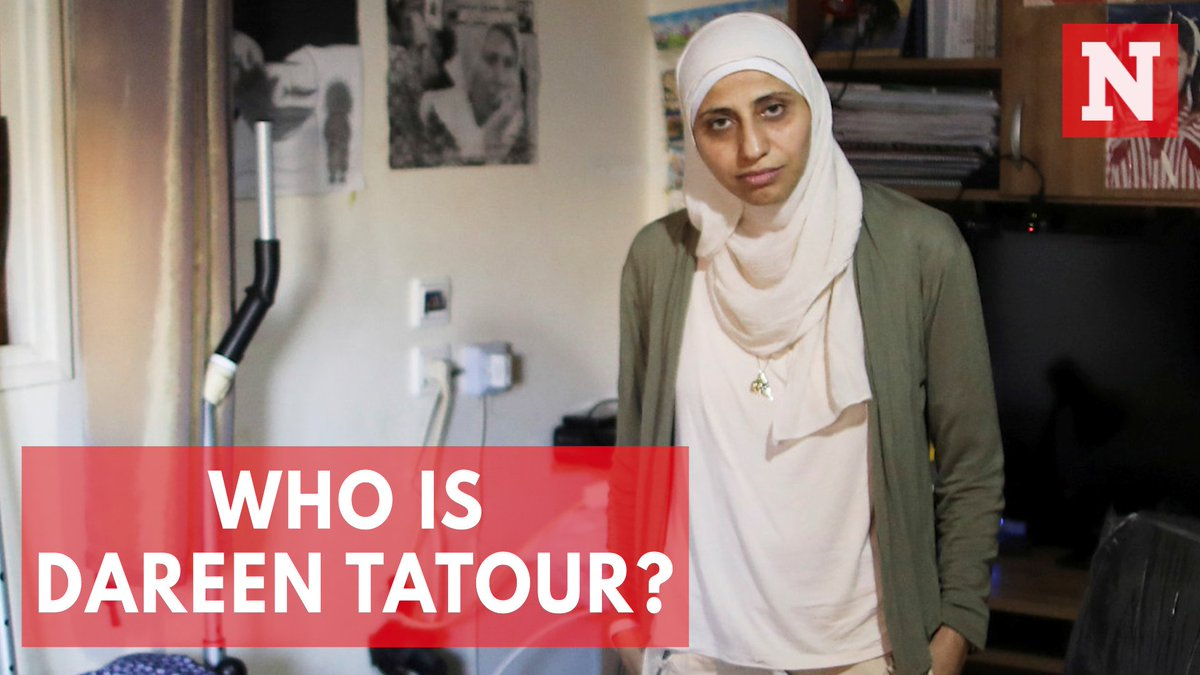

In [5]:
# Confirm a sample image opens correctly
Image.open(image_df["image_path"].iloc[0])

## 3. BLIP Captioning Layer

We use `Salesforce/blip-image-captioning-base` to generate a natural-language description for each image.

This replaces the weak Top-K ImageNet/Places365 labels used in the visual-only pipeline. Instead of `"military uniform (0.23)"`, the LLM receives `"a man in a white suit is escorted by police"` — a full sentence that encodes spatial, relational, and semantic structure that RoBERTa and the LLM can actually reason about.

The BLIP captions will later be compared against the original post `content` via MPNet to detect text-image misalignment.

In [6]:
# ============================================================
# 3. BLIP CAPTIONING LAYER
# ============================================================

print("--- [3] Loading BLIP model ---")

blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME)
blip_model     = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_NAME).eval()
blip_model.to(device)
print("BLIP model loaded.")

--- [3] Loading BLIP model ---


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 473/473 [00:00<00:00, 1368.49it/s, Materializing param=vision_model.post_layernorm.weight]                                       
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT 

BLIP model loaded.


In [7]:
def generate_caption(image_path: str) -> str:
    """
    Generates a natural-language caption for a single image using BLIP.
    Returns a plain-text string.
    """
    image  = Image.open(image_path).convert("RGB")
    inputs = blip_processor(image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=100)

    return blip_processor.decode(out[0], skip_special_tokens=True)


# Quick test on first image
first_img  = image_df["image_path"].iloc[0]
first_text = image_df["content"].iloc[0]
first_cap  = generate_caption(first_img)

print(f"Original post text : {first_text[:120]}")
print(f"BLIP caption       : {first_cap}")

Original post text : Who is Dareen Tatour, the Palestinian poet sent to Israeli prison after writing a poem titled 'Resist, my people, resist
BLIP caption       : a woman in a white shirt and a green jacket stands in a room with a red wall


In [8]:
# Generate captions for all samples
captions = [
    generate_caption(row["image_path"])
    for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc="BLIP captioning")
]

image_df["blip_caption"] = captions

print("\nCaption generation done.")
image_df[["content", "blip_caption", "label_name"]].head(6)

BLIP captioning: 100%|██████████| 200/200 [02:18<00:00,  1.44it/s]


Caption generation done.


,content,blip_caption,label_name
0,"Who is Dareen Tatour, the Palestinian poet sent to Israeli prison after writ...",a woman in a white shirt and a green jacket stands in a room with a red wall,real_news
1,"She's 1,300 lbs, moves 'like a potato sack', and just wants a place to nap: ...",a seal is in the water with a camera,real_news
2,Introducing the World's Most Valuable Soccer Teams \t\tFULL LIST: https://t....,a shirt in a glass case with the words ' world ' s valuable teams ',real_news
3,Double Olympic champion #GuAiling of China secured her third #XGames gold me...,"prince charles, duke of edinburgh",entity_inconsistency
4,Everett Stern alleged reps for the former national security adviser approach...,"president obama and his wife, michelle, are seen in the oval room of the whi...",real_news
5,"What’s the major takeaway from Elon Musk's ""Twitter Files""? @karaswisher tel...",a woman wearing headphones is on the news,real_news


## 4. Text Similarity Layer (MPNet)

We compute the **cosine similarity** between the original post `content` and the BLIP-generated caption using `all-mpnet-base-v2`.

This is the key fusion signal: for real news, the image should depict what the post actually describes, so the caption and post should be semantically aligned. For fake news (especially AMG types like entity or event inconsistency), the image was misused — so the BLIP caption will describe something that doesn't match the original post text, resulting in a lower similarity score.

Similarity ranges:
- **High (> 0.5)** — image and post describe the same event/content → likely aligned → possibly real
- **Medium (0.2–0.5)** — partial overlap → ambiguous
- **Low (< 0.2)** — image and post describe unrelated things → potential manipulation signal

In [9]:
# ============================================================
# 4. TEXT SIMILARITY LAYER (MPNet)
# ============================================================

print("--- [4] Loading MPNet similarity model ---")

sim_model = SentenceTransformer(MPNET_MODEL)
print("MPNet model loaded.")


def compute_similarity(text1: str, text2: str) -> float:
    """
    Returns the cosine similarity between two text strings in [-1, 1].
    """
    emb1 = sim_model.encode(text1, convert_to_tensor=True)
    emb2 = sim_model.encode(text2, convert_to_tensor=True)
    return float(st_util.cos_sim(emb1, emb2).item())


# Show first example
ex_content = image_df["content"].iloc[0]
ex_caption = image_df["blip_caption"].iloc[0]
ex_sim     = compute_similarity(ex_content, ex_caption)

print(f"\nContent : {ex_content[:100]}")
print(f"Caption : {ex_caption}")
print(f"Similarity score: {ex_sim:.4f}")

--- [4] Loading MPNet similarity model ---


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 954.51it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MPNet model loaded.

Content : Who is Dareen Tatour, the Palestinian poet sent to Israeli prison after writing a poem titled 'Resis
Caption : a woman in a white shirt and a green jacket stands in a room with a red wall
Similarity score: 0.0527


In [10]:
# Compute similarity scores for all samples
similarity_scores = [
    compute_similarity(row["content"], row["blip_caption"])
    for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Computing similarity")
]

image_df["similarity"] = similarity_scores

# Summary statistics by binary label
print("\nSimilarity score statistics by label:")
print(image_df.groupby("label")["similarity"].describe().round(4))

Computing similarity: 100%|██████████| 200/200 [00:13<00:00, 14.40it/s]


Similarity score statistics by label:
       count    mean     std     min     25%     50%     75%     max
label                                                               
0       18.0  0.1067  0.1098 -0.0185  0.0304  0.0815  0.1415  0.4209
1      182.0  0.1883  0.1573 -0.0546  0.0623  0.1538  0.2866  0.8042


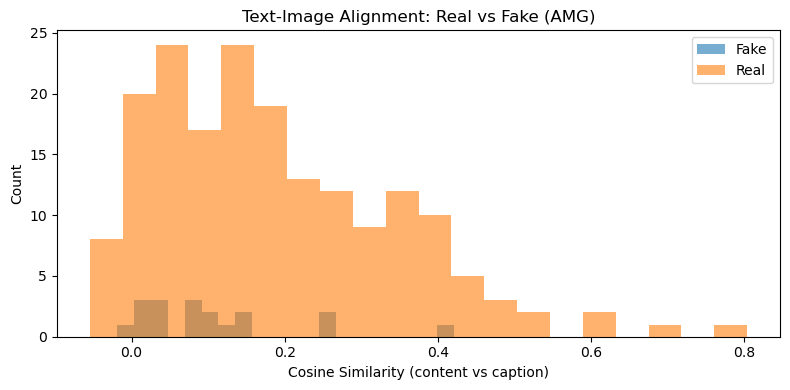

In [11]:
# Similarity distribution plot: Real vs Fake
fig, ax = plt.subplots(figsize=(8, 4))
for lbl, grp in image_df.groupby("label"):
    ax.hist(grp["similarity"], bins=20, alpha=0.6,
            label="Real" if lbl == 1 else "Fake")
ax.set_xlabel("Cosine Similarity (content vs caption)")
ax.set_ylabel("Count")
ax.set_title("Text-Image Alignment: Real vs Fake (AMG)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. RoBERTa Prediction Layer

We run `hamzab/roberta-fake-news-classification` on **both** the original post text and the BLIP caption independently.

This is a key improvement over the reference notebooks which used `roberta-base-openai-detector` (a model trained to detect AI-generated text — misaligned with the fake news task). `hamzab/roberta-fake-news-classification` is purpose-trained for fake news detection, giving more meaningful confidence scores.

Running it on both text views gives us two independent signals:
- **text prediction**: does the original post *read* like fake news?
- **caption prediction**: does what the image *shows* look like fake news context?

In [12]:
# ============================================================
# 5. ROBERTA PREDICTION LAYER
# ============================================================

print("--- [5] Loading RoBERTa model ---")

roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL)
roberta_model     = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL)
roberta_model.to(device)
roberta_model.eval()
print("RoBERTa model loaded.")

--- [5] Loading RoBERTa model ---


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1341.93it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: hamzab/roberta-fake-news-classification
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa model loaded.


In [13]:
def classify_with_roberta(text: str):
    """
    Classifies a text string using hamzab/roberta-fake-news-classification.

    Label convention (same as TextAgent_AMG):
      index 0 -> fake
      index 1 -> real

    Returns:
      pred_label  : 'fake' or 'real'
      confidence  : softmax probability of the winning class
      fake_score  : probability of fake
      real_score  : probability of real
    """
    text   = str(text).replace("\n", " ").strip()
    inputs = roberta_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=256
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = roberta_model(**inputs)
        probs   = F.softmax(outputs.logits, dim=1).squeeze()

    fake_score = float(probs[0].item())
    real_score = float(probs[1].item())
    pred_idx   = int(torch.argmax(probs).item())
    pred_label = "fake" if pred_idx == 0 else "real"
    confidence = float(probs[pred_idx].item())

    return pred_label, confidence, fake_score, real_score


# Run RoBERTa on original post content
print("Running RoBERTa on original post content...")
text_results = [
    classify_with_roberta(t)
    for t in tqdm(image_df["content"], desc="RoBERTa (content)")
]
image_df["text_pred"]   = [r[0] for r in text_results]
image_df["text_conf"]   = [r[1] for r in text_results]
image_df["text_fake_p"] = [r[2] for r in text_results]
image_df["text_real_p"] = [r[3] for r in text_results]

# Run RoBERTa on BLIP captions
print("Running RoBERTa on BLIP captions...")
cap_results = [
    classify_with_roberta(c)
    for c in tqdm(image_df["blip_caption"], desc="RoBERTa (caption)")
]
image_df["cap_pred"]   = [r[0] for r in cap_results]
image_df["cap_conf"]   = [r[1] for r in cap_results]
image_df["cap_fake_p"] = [r[2] for r in cap_results]
image_df["cap_real_p"] = [r[3] for r in cap_results]

print("\nRoBERTa predictions done.")
print("\nContent text predictions:",  image_df["text_pred"].value_counts().to_dict())
print("BLIP caption predictions:",   image_df["cap_pred"].value_counts().to_dict())

Running RoBERTa on original post content...


RoBERTa (content): 100%|██████████| 200/200 [00:07<00:00, 25.11it/s]


Running RoBERTa on BLIP captions...


RoBERTa (caption): 100%|██████████| 200/200 [00:04<00:00, 45.76it/s]


RoBERTa predictions done.

Content text predictions: {'fake': 137, 'real': 63}
BLIP caption predictions: {'fake': 160, 'real': 40}


## 6. OpenRouter LLM Reasoning Layer

We now fuse all signals into a single prompt and ask `gpt-4.1-mini` via OpenRouter for a final decision.

The LLM receives:
- the original post text + RoBERTa prediction and confidence
- the BLIP-generated image caption + RoBERTa prediction and confidence
- the MPNet cosine similarity score between the two texts

The prompt instructs the LLM to treat the **similarity score as the most discriminative signal** — low similarity suggests the image was misused relative to what the post claims, which is the core mechanism behind most AMG fake categories.

In [14]:
# ============================================================
# 6. OPENROUTER LLM REASONING LAYER
# ============================================================

print("--- [6] OpenRouter LLM reasoning layer ---")


def build_fusion_prompt(
    content, text_pred, text_conf,
    blip_caption, cap_pred, cap_conf,
    similarity_score
):
    return f"""You are a misinformation detection assistant.

ORIGINAL POST TEXT:
\"{content}\"
A fake-news classifier predicted this text is: {text_pred} (confidence: {text_conf:.2f})

AI-GENERATED IMAGE CAPTION:
\"{blip_caption}\"
A fake-news classifier predicted this caption is: {cap_pred} (confidence: {cap_conf:.2f})

SEMANTIC ALIGNMENT:
Cosine similarity between the post text and the image caption: {similarity_score:.2f}
(High similarity means the image matches the post; low similarity may indicate image misuse.)

Instructions:
1. Treat the similarity score as the strongest single signal — low similarity suggests manipulation.
2. Use the classifier predictions as supporting evidence, weighted by their confidence.
3. Consider whether the post text and image caption describe the same event, people, and place.
4. You must output exactly one label: Real or Fake.
5. Do not output uncertain, mixed, or unknown.

Respond EXACTLY in this format:
- Decision: Real or Fake
- Explanation: 2 concise sentences
- Nudge: 1 practical suggestion for verification
""".strip()


def query_openrouter(prompt, model=OPENROUTER_MODEL, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                temperature=0,
                max_tokens=150,
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "You are an independent misinformation detection assistant. "
                            "Provide concise, structured outputs."
                        )
                    },
                    {"role": "user", "content": prompt}
                ]
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            print("OpenRouter API error:", repr(e))
            if attempt == max_retries - 1:
                return f"- Decision: Error\n- Explanation: API failed: {str(e)}\n- Nudge: None"
            time.sleep(2)


def parse_field(resp, key):
    m = re.search(rf"-\s*{key}\s*:\s*(.*)", str(resp), flags=re.IGNORECASE)
    return m.group(1).strip() if m else ""


# --- Quick single test ---
test_row    = image_df.iloc[0]
test_prompt = build_fusion_prompt(
    content          = test_row["content"],
    text_pred        = test_row["text_pred"],
    text_conf        = test_row["text_conf"],
    blip_caption     = test_row["blip_caption"],
    cap_pred         = test_row["cap_pred"],
    cap_conf         = test_row["cap_conf"],
    similarity_score = test_row["similarity"]
)
print("\n--- OpenRouter test call ---")
print(query_openrouter(test_prompt))


# --- Main execution loop ---
results = []

for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Running Fusion Agent (AMG)"):
    prompt  = build_fusion_prompt(
        content          = row["content"],
        text_pred        = row["text_pred"],
        text_conf        = row["text_conf"],
        blip_caption     = row["blip_caption"],
        cap_pred         = row["cap_pred"],
        cap_conf         = row["cap_conf"],
        similarity_score = row["similarity"]
    )
    llm_out = query_openrouter(prompt)

    results.append({
        "orig_id"      : row["orig_id"],
        "image_path"   : row["image_path"],
        "content"      : row["content"],
        "blip_caption" : row["blip_caption"],
        "label_name"   : row["label_name"],
        "true_label"   : row["label"],
        "text_pred"    : row["text_pred"],
        "text_conf"    : row["text_conf"],
        "cap_pred"     : row["cap_pred"],
        "cap_conf"     : row["cap_conf"],
        "similarity"   : row["similarity"],
        "llm_response" : llm_out,
    })

results_df = pd.DataFrame(results)

# Parse LLM fields
results_df["llm_decision"]    = results_df["llm_response"].apply(lambda r: parse_field(r, "Decision"))
results_df["llm_explanation"] = results_df["llm_response"].apply(lambda r: parse_field(r, "Explanation"))
results_df["llm_nudge"]       = results_df["llm_response"].apply(lambda r: parse_field(r, "Nudge"))

print("\n--- LLM decision distribution ---")
print(results_df["llm_decision"].value_counts(dropna=False))

--- [6] OpenRouter LLM reasoning layer ---

--- OpenRouter test call ---
- Decision: Fake  
- Explanation: The very low semantic similarity (0.05) indicates the image does not correspond to the post text about Dareen Tatour. Additionally, the high confidence fake-news prediction for the post text supports that the claim is likely false or misleading.  
- Nudge: Verify the identity and context of Dareen Tatour through reputable news sources or official statements before sharing.


Running Fusion Agent (AMG): 100%|██████████| 200/200 [06:02<00:00,  1.81s/it]


--- LLM decision distribution ---
llm_decision
Fake    197
Real      3
Name: count, dtype: int64


In [15]:
# Display results table
results_df[[
    "content", "blip_caption", "similarity",
    "true_label", "text_pred", "cap_pred",
    "llm_decision", "llm_explanation", "llm_nudge"
]]

,content,blip_caption,similarity,true_label,text_pred,cap_pred,llm_decision,llm_explanation,llm_nudge
0,"Who is Dareen Tatour, the Palestinian poet sent to Israeli prison after writ...",a woman in a white shirt and a green jacket stands in a room with a red wall,0.052709,1,fake,real,Fake,The very low semantic similarity (0.05) indicates the image does not corresp...,Verify the identity and story of Dareen Tatour through reputable news source...
1,"She's 1,300 lbs, moves 'like a potato sack', and just wants a place to nap: ...",a seal is in the water with a camera,0.206525,1,fake,fake,Fake,The very low semantic similarity (0.21) indicates the image does not corresp...,Verify the identity and story of Freya the walrus through reputable wildlife...
2,Introducing the World's Most Valuable Soccer Teams \t\tFULL LIST: https://t....,a shirt in a glass case with the words ' world ' s valuable teams ',0.427505,1,fake,fake,Fake,The low semantic similarity (0.43) indicates the image does not accurately r...,Verify the authenticity by checking reputable sports finance sources or offi...
3,Double Olympic champion #GuAiling of China secured her third #XGames gold me...,"prince charles, duke of edinburgh",0.084739,0,real,fake,Fake,"The image caption references Prince Charles, unrelated to the skiing event d...",Verify the image by reverse searching it to confirm if it matches the event ...
4,Everett Stern alleged reps for the former national security adviser approach...,"president obama and his wife, michelle, are seen in the oval room of the whi...",0.104316,1,real,real,Fake,The very low semantic similarity (0.10) between the post text about Everett ...,Verify the image source and context independently to confirm if it relates t...
...,...,...,...,...,...,...,...,...,...
195,"Celebrate 50 years of the #GratefulDead in Newsweek's special issue, on sale...",grateful grateful grateful grateful grateful grateful grateful grateful grat...,0.348946,1,fake,fake,Fake,The very low semantic similarity (0.35) between the post text and the repeti...,Verify the Newsweek special issue directly from official Newsweek sources or...
196,Batter up!\t\tFans at this Saturday’s World Series matchup between the Atlan...,donald trump and the president of the united,0.338957,1,real,fake,Fake,The low semantic similarity (0.34) between the post text and image caption i...,Verify the presence of Donald Trump at the World Series through reputable ne...
197,UK extends truck driver visa program as fuel crisis persists https://t.co/lS...,a man in a suit and tie is pointing at a tv screen,0.026473,1,real,fake,Fake,The very low semantic similarity (0.03) indicates the image does not corresp...,Verify the image source and check official UK government announcements for c...
198,ABORTION: Gloria Steinem speaks in front of Congress and warns that abortion...,a woman in a suit and tie sitting at a podium,0.182274,1,fake,fake,Fake,The very low semantic similarity (0.18) indicates the image does not depict ...,Verify the original source of the video or image by checking reputable news ...


## 7. Evaluation

We compare three classifiers:
1. **RoBERTa on post content** — text-only baseline
2. **RoBERTa on BLIP caption** — image-derived text baseline
3. **LLM fusion** — all signals combined

Metrics: accuracy, LLM coverage, confusion matrices (3 side-by-side), classification reports.

In [16]:
# ============================================================
# 7. EVALUATION
# ============================================================

print("--- [7] Evaluation ---")


def label_to_int(x):
    x = str(x).strip().lower()
    if x == "fake": return 0
    if x == "real": return 1
    return None


results_df["true_label"]  = results_df["true_label"].astype(int)
results_df["text_label"]  = results_df["text_pred"].apply(label_to_int)
results_df["cap_label"]   = results_df["cap_pred"].apply(label_to_int)
results_df["llm_label"]   = results_df["llm_decision"].apply(label_to_int)

llm_clean = results_df.dropna(subset=["llm_label"]).copy()
llm_clean["llm_label"] = llm_clean["llm_label"].astype(int)

# Accuracies
text_acc = accuracy_score(results_df["true_label"], results_df["text_label"])
cap_acc  = accuracy_score(results_df["true_label"], results_df["cap_label"])
llm_acc  = accuracy_score(llm_clean["true_label"],  llm_clean["llm_label"]) if len(llm_clean) > 0 else float("nan")
llm_cov  = len(llm_clean) / len(results_df)

print(f"RoBERTa (content text) Accuracy : {text_acc:.3f}")
print(f"RoBERTa (BLIP caption) Accuracy : {cap_acc:.3f}")
print(f"LLM Fusion Accuracy             : {llm_acc:.3f}" if len(llm_clean) > 0 else "LLM Accuracy: nan")
print(f"LLM Coverage                    : {llm_cov:.3f}")

# Confusion matrices
text_cm = confusion_matrix(results_df["true_label"], results_df["text_label"])
cap_cm  = confusion_matrix(results_df["true_label"], results_df["cap_label"])
llm_cm  = confusion_matrix(llm_clean["true_label"],  llm_clean["llm_label"]) if len(llm_clean) > 0 else None

print("\nRoBERTa (Content) Confusion Matrix:\n", text_cm)
print("\nRoBERTa (Caption) Confusion Matrix:\n", cap_cm)
if llm_cm is not None:
    print("\nLLM Fusion Confusion Matrix:\n", llm_cm)

--- [7] Evaluation ---
RoBERTa (content text) Accuracy : 0.375
RoBERTa (BLIP caption) Accuracy : 0.270
LLM Fusion Accuracy             : 0.105
LLM Coverage                    : 1.000

RoBERTa (Content) Confusion Matrix:
 [[ 15   3]
 [122  60]]

RoBERTa (Caption) Confusion Matrix:
 [[ 16   2]
 [144  38]]

LLM Fusion Confusion Matrix:
 [[ 18   0]
 [179   3]]


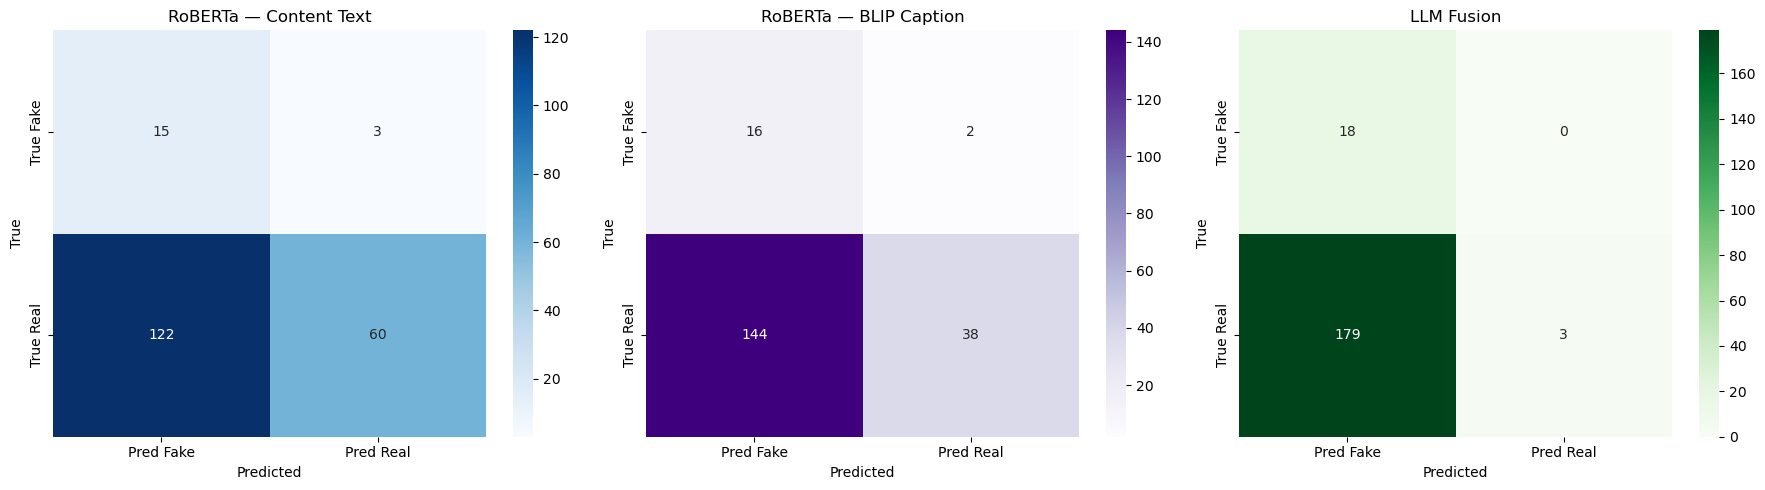

>>> Fusion pipeline (AMG) complete.


In [17]:
# Heatmaps — 3 side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(text_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"], ax=axes[0])
axes[0].set_title("RoBERTa — Content Text")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cap_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"], ax=axes[1])
axes[1].set_title("RoBERTa — BLIP Caption")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

if llm_cm is not None:
    sns.heatmap(llm_cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["Pred Fake", "Pred Real"],
                yticklabels=["True Fake", "True Real"], ax=axes[2])
    axes[2].set_title("LLM Fusion")
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
else:
    axes[2].axis("off")
    axes[2].set_title("LLM Fusion — unavailable")

plt.tight_layout()
plt.show()

print(">>> Fusion pipeline (AMG) complete.")

In [18]:
# Classification reports
print("\n-----------------------------------------------------")
print("RoBERTa (Content Text) Classification Report")
print("-----------------------------------------------------")
print(classification_report(results_df["true_label"], results_df["text_label"], target_names=["Fake", "Real"]))

print("\n-----------------------------------------------------")
print("RoBERTa (BLIP Caption) Classification Report")
print("-----------------------------------------------------")
print(classification_report(results_df["true_label"], results_df["cap_label"], target_names=["Fake", "Real"]))

if len(llm_clean) > 0:
    print("\n-----------------------------------------------------")
    print("LLM Fusion Classification Report")
    print("-----------------------------------------------------")
    print(classification_report(llm_clean["true_label"], llm_clean["llm_label"], target_names=["Fake", "Real"]))


-----------------------------------------------------
RoBERTa (Content Text) Classification Report
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.11      0.83      0.19        18
        Real       0.95      0.33      0.49       182

    accuracy                           0.38       200
   macro avg       0.53      0.58      0.34       200
weighted avg       0.88      0.38      0.46       200


-----------------------------------------------------
RoBERTa (BLIP Caption) Classification Report
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.10      0.89      0.18        18
        Real       0.95      0.21      0.34       182

    accuracy                           0.27       200
   macro avg       0.53      0.55      0.26       200
weighted avg       0.87      0.27      0.33       200


-------------------------------------

## 8. Dataset Inspection + Error Analysis

We inspect the processed dataset and break errors into cases:
1. Both RoBERTa classifiers agree but LLM disagrees
2. Both wrong
3. LLM corrects both RoBERTa classifiers

We also look at similarity score distributions for correctly vs incorrectly classified samples to validate whether text-image alignment is indeed a useful signal.

In [19]:
# ============================================================
# 8. DATASET INSPECTION + ERROR ANALYSIS
# ============================================================

print("--- Dataset quick inspection ---")
print("Shape:", results_df.shape)
print("\nColumns:", results_df.columns.tolist())

print("\nAMG label breakdown (sample):")
print(results_df["label_name"].value_counts())

print("\nBinary label distribution:")
print(results_df["true_label"].value_counts().sort_index())   # 0=Fake, 1=Real

print("\nMissing values per column:")
print(results_df.isnull().sum())

--- Dataset quick inspection ---
Shape: (200, 18)

Columns: ['orig_id', 'image_path', 'content', 'blip_caption', 'label_name', 'true_label', 'text_pred', 'text_conf', 'cap_pred', 'cap_conf', 'similarity', 'llm_response', 'llm_decision', 'llm_explanation', 'llm_nudge', 'text_label', 'cap_label', 'llm_label']

AMG label breakdown (sample):
label_name
real_news                         182
entity_inconsistency                8
ineffective_visual_information      4
time_space_inconsistency            3
event_inconsistency                 2
image_fabrication                   1
Name: count, dtype: int64

Binary label distribution:
true_label
0     18
1    182
Name: count, dtype: int64

Missing values per column:
orig_id            0
image_path         0
content            0
blip_caption       0
label_name         0
true_label         0
text_pred          0
text_conf          0
cap_pred           0
cap_conf           0
similarity         0
llm_response       0
llm_decision       0
llm_explana

In [20]:
# Similarity score statistics: correct vs incorrect LLM predictions
correct   = llm_clean[llm_clean["llm_label"] == llm_clean["true_label"]]
incorrect = llm_clean[llm_clean["llm_label"] != llm_clean["true_label"]]

print(f"Correct LLM predictions   : {len(correct)}  | mean similarity: {correct['similarity'].mean():.4f}")
print(f"Incorrect LLM predictions : {len(incorrect)} | mean similarity: {incorrect['similarity'].mean():.4f}")

Correct LLM predictions   : 21  | mean similarity: 0.1876
Incorrect LLM predictions : 179 | mean similarity: 0.1801


In [21]:
# Error cases
both_roberta_correct = results_df[
    (results_df["text_label"] == results_df["true_label"]) &
    (results_df["cap_label"]  == results_df["true_label"]) &
    (results_df["llm_label"]  != results_df["true_label"])
]
llm_recovers_both = results_df[
    (results_df["text_label"] != results_df["true_label"]) &
    (results_df["cap_label"]  != results_df["true_label"]) &
    (results_df["llm_label"]  == results_df["true_label"])
]
all_wrong = results_df[
    (results_df["text_label"] != results_df["true_label"]) &
    (results_df["cap_label"]  != results_df["true_label"]) &
    (results_df["llm_label"]  != results_df["true_label"])
]

for name, df_case in [
    ("Both RoBERTa correct, LLM wrong", both_roberta_correct),
    ("LLM corrects both RoBERTa",       llm_recovers_both),
    ("All three wrong",                 all_wrong)
]:
    print(f"\n===== {name} ({len(df_case)} rows) =====")
    for i, (_, row) in enumerate(df_case.head(3).iterrows(), 1):
        print(f"\nExample {i}")
        print("-" * 70)
        print("Content    :", str(row["content"])[:120])
        print("Caption    :", row["blip_caption"])
        print("Similarity :", round(row["similarity"], 4))
        print("True label :", row["true_label"], "(", row["label_name"], ")")
        print("RoBERTa (text)   :", row["text_pred"], f"conf={row['text_conf']:.2f}")
        print("RoBERTa (caption):", row["cap_pred"],  f"conf={row['cap_conf']:.2f}")
        print("LLM decision     :", row["llm_decision"])
        print("LLM explanation  :", row["llm_explanation"])


===== Both RoBERTa correct, LLM wrong (15 rows) =====

Example 1
----------------------------------------------------------------------
Content    : Everett Stern alleged reps for the former national security adviser approached him with the objective to influence lawma
Caption    : president obama and his wife, michelle, are seen in the oval room of the white house on march 29
Similarity : 0.1043
True label : 1 ( real_news )
RoBERTa (text)   : real conf=0.86
RoBERTa (caption): real conf=1.00
LLM decision     : Fake
LLM explanation  : The very low semantic similarity (0.10) between the post text about Everett Stern and election audits and the image caption describing President Obama and Michelle Obama in the White House indicates a mismatch. Despite high confidence in the classifiers, the unrelated content suggests the image is misused or irrelevant to the post.

Example 2
----------------------------------------------------------------------
Content    : Officials are already seeing a

In [22]:
# Most and least aligned pairs in the sample
sorted_df = results_df.sort_values("similarity", ascending=False)

print("\n-----------------------------------------------------")
print("Most Aligned Pairs (Highest Similarity)")
print("-----------------------------------------------------")
for _, row in sorted_df.head(3).iterrows():
    print(f"Score: {row['similarity']:.4f} | True: {'Real' if row['true_label']==1 else 'Fake'} | LLM: {row['llm_decision']}")
    print(f"  Content : {str(row['content'])[:100]}")
    print(f"  Caption : {row['blip_caption']}")

print("\n-----------------------------------------------------")
print("Most Misaligned Pairs (Lowest Similarity)")
print("-----------------------------------------------------")
for _, row in sorted_df.tail(3).iterrows():
    print(f"Score: {row['similarity']:.4f} | True: {'Real' if row['true_label']==1 else 'Fake'} | LLM: {row['llm_decision']}")
    print(f"  Content : {str(row['content'])[:100]}")
    print(f"  Caption : {row['blip_caption']}")


-----------------------------------------------------
Most Aligned Pairs (Highest Similarity)
-----------------------------------------------------
Score: 0.8042 | True: Real | LLM: Real
  Content : China bans citizens from traveling to Taiwan as individual tourists https://t.co/RSGWzT5QLS https://
  Caption : china bans from traveling to taiwan ' s individual tours
Score: 0.7009 | True: Real | LLM: Fake
  Content : This is the world's tallest statue https://t.co/zaqpndewHv https://t.co/aoAvlfS7Lf
  Caption : the statue of unity in india with the words world ' s tallest statue
Score: 0.6170 | True: Real | LLM: Real
  Content : On Sunday, elephants in Ringling Bros. circus will take their final bows: https://t.co/YiJSmeatcq ht
  Caption : elephants perform on stage during the opening night of the circus

-----------------------------------------------------
Most Misaligned Pairs (Lowest Similarity)
-----------------------------------------------------
Score: -0.0516 | True: Real | LLM: